In [15]:
# ## dict --> csv 로 변경하는 코드, 지금은 필요없음
# import pandas as pd

# def dict_to_dataframe(ppl_plots):
#     rows = []
#     for model_name, experiments in ppl_plots.items():
#         for exp_name, metrics in experiments.items():
#             # 1. 반복 횟수(데이터 포인트 수) 결정
#             if 'bpp' in metrics:
#                 n_points = len(metrics['bpp'])
#             elif 'lambda' in metrics:
#                 n_points = len(metrics['lambda'])
#             elif exp_name == 'FP16':
#                 n_points = 1 
#             else:
#                 print('Missing metrics for logic: ', model_name, exp_name)
#                 # [수정] n_points가 정의되지 않은 상태로 아래 루프에 진입하지 않도록 건너뜁니다.
#                 continue 

#             for i in range(n_points):
#                 row = {
#                     'Model': model_name,
#                     'Experiment': exp_name
#                 }
                
#                 for metric_name, values in metrics.items():
#                     # 리스트인 경우 해당 인덱스 값 추출
#                     if isinstance(values, list):
#                         if i < len(values):
#                             row[metric_name] = values[i]
#                     # 단일 값(int, float, str)인 경우 그대로 사용
#                     elif isinstance(values, (int, float, str)):
#                         row[metric_name] = values
                        
#                 rows.append(row)
    
#     return pd.DataFrame(rows)

# def dataframe_to_dict(df):
#     restored_dict = {}
    
#     # 1. Model과 Experiment를 기준으로 그룹핑
#     # sort=False: 데이터프레임에 정렬된 순서(bpp 순)를 그대로 유지하기 위해 중요함
#     grouped = df.groupby(['Model', 'Experiment'], sort=False)
    
#     for (model, exp), group in grouped:
#         if model not in restored_dict:
#             restored_dict[model] = {}
        
#         restored_dict[model][exp] = {}
        
#         # 2. 메트릭 컬럼들만 순회 (Model, Experiment 컬럼 제외)
#         metric_cols = [c for c in group.columns if c not in ['Model', 'Experiment']]
        
#         for col in metric_cols:
#             # 3. 중요: 해당 실험에서 데이터가 하나라도 있는 컬럼만 저장
#             # (다른 실험에는 있는데 이 실험엔 없어서 전원 NaN인 컬럼은 딕셔너리 키에서 제외)
#             if group[col].notna().any():
#                 # 리스트로 변환 (NaN도 포함되어 위치 정보 유지됨)
#                 restored_dict[model][exp][col] = group[col].tolist()
                
#     return restored_dict


In [16]:
import os
import shutil
import pandas as pd
from datetime import datetime
from zoneinfo import ZoneInfo

def _timestamp_kr():
    return datetime.now(ZoneInfo("Asia/Seoul")).strftime("%Y%m%d_%H%M%S")

def save_update_csv_in_timefolder(base_path, df, ts=None, **kwargs):
    """
    기존 CSV 파일이 있으면 {dirname}/save/{ts}/{basename}.csv 에 백업하고,
    새로운 DataFrame을 base_path에 저장합니다.
    
    Args:
        base_path (str): 저장할 메인 파일 경로 (예: ./results/summary.csv)
        df (pd.DataFrame): 저장할 데이터프레임
        ts (str): 타임스탬프 (None이면 자동 생성)
        **kwargs: df.to_csv()에 전달할 추가 인자 (예: sep='\t')
    
    Returns:
        (archived_path, base_path): 백업된 경로와 저장된 경로
    """
    
    # 1. 타임스탬프 및 경로 설정
    if ts is None:
        ts = _timestamp_kr()
        
    parent = os.path.dirname(base_path) or "."
    fname = os.path.basename(base_path)
    archived_path = None

    # 2. 아카이브: 기존 파일이 존재하면 save 폴더로 복사(백업)
    if os.path.exists(base_path):
        out_dir = os.path.join(parent, 'save', ts)
        os.makedirs(out_dir, exist_ok=True)
        archived_path = os.path.join(out_dir, fname)
        
        # 단순 파일 복사 (가장 안전하고 빠름)
        shutil.copy2(base_path, archived_path)

    # 3. 저장: 임시 파일에 쓰고 원본 교체 (Atomic Write)
    # 저장 경로 생성
    os.makedirs(parent, exist_ok=True)
    
    tmp_path = base_path + ".tmp"
    
    # 기본값 index=False 설정 (kwargs로 덮어쓰기 가능)
    save_kwargs = {'index': False} 
    save_kwargs.update(kwargs)
    
    df.to_csv(tmp_path, **save_kwargs)
    
    # 임시 파일을 원본 파일명으로 교체
    os.replace(tmp_path, base_path)

    return archived_path, base_path

# Read results

In [17]:
import glob
import json
import re
import pandas as pd
import numpy as np

# ---------------------------------------------------------
# 1. 헬퍼 함수 정의 (계산 및 파싱 로직)
# ---------------------------------------------------------
def extract_key_from_filename(filename):
    """파일 이름에서 실험 식별자(lambda, bit, w)를 추출 (소수점 지원)"""
    
    # 1. Lambda 수정: (\d+(\.\d+)?) 패턴을 사용하여 소수점 포함 숫자 추출
    # 예: lmbda2 -> 2, lmbda2.5 -> 2.5
    m_lambda = re.search(r'lmbda(\d+(\.\d+)?)', filename)
    if m_lambda: 
        val = float(m_lambda.group(1))
        # 2.0 처럼 정수로 떨어지면 int로, 2.5면 float로 반환
        return int(val) if val.is_integer() else val
    
    # 2. Bit 수정: (혹시 모를 소수 비트 지원)
    m_bit = re.search(r'(\d+(\.\d+)?)\s*bit', filename.lower())
    if m_bit: 
        val = float(m_bit.group(1))
        return int(val) if val.is_integer() else val
        
    # 3. W 수정: w0.5, w1.0 등 지원
    m_w = re.search(r'w(\d+(\.\d+)?)', filename.lower())
    if m_w: 
        val = float(m_w.group(1))
        return int(val) if val.is_integer() else val
        
    if 'base' in filename.lower():
        return 'base'
        
    return None

def cal_mse_from_json(result):
    sum_mse = 0
    total_n = 0
    for k,v in result.items():
        if not k.endswith('.pt'): continue
        sum_mse += v['mse'] * v['num_pixels']
        total_n += v['num_pixels']
    return sum_mse / total_n if total_n > 0 else 0

def cal_mse_normed_from_json(result):
    sum_mse = 0
    total_n = 0
    for k,v in result.items():
        if not k.endswith('.pt'): continue
        sum_mse += v['mse_normed'] * v['num_pixels']
        total_n += v['num_pixels']
    return sum_mse / total_n if total_n > 0 else 0

def cal_proxy_loss_from_json(result):
    sum_val = 0
    total_n = 0
    for k,v in result.items():
        if not k.endswith('.pt'): continue
        sum_val += v['proxy_err']
        total_n += 1
    return sum_val / total_n if total_n > 0 else 0

# ---------------------------------------------------------
# 2. 메인 로딩 함수
# ---------------------------------------------------------
def load_new_results_to_dataframe(path_list, tasks=None, tasksets=None):
    """
    지정된 경로 리스트에서 json 파일들을 읽어 DataFrame으로 반환합니다.
    
    Args:
        path_list (list): 실험 결과가 있는 디렉토리 경로 리스트
        tasks (list): Zero-shot 태스크 이름 리스트 (None일 경우 기본값 사용)
        tasksets (dict): 평균을 낼 태스크 그룹 정의 (None일 경우 기본값 사용)
        
    Returns:
        pd.DataFrame: 모든 실험 결과가 병합된 DataFrame
    """
    
    # 기본값 설정
    if tasks is None:
        tasks = ['arc_challenge', 'arc_easy', 'boolq', 'piqa', 'winogrande', 'hellaswag', 'mmlu', 'mathqa', 'openbookqa', 'pubmedqa', 'sciq']
    
    if tasksets is None:
        tasksets = {
            'zeroshot': ['arc_challenge', 'arc_easy', 'boolq', 'piqa', 'winogrande'], 
            'commonsense': ['arc_challenge', 'arc_easy', 'boolq', 'piqa', 'winogrande', 'hellaswag'], 
            'mmlu': ['mmlu'],
        }

    df_list = []

    for path in path_list:
        # 경로 깊이에 따라 인덱스 조절 필요 (기본: 7번째부터 잘라서 이름 생성)
        # 만약 경로가 짧으면 전체 폴더명을 사용하도록 예외 처리
        parts = path.split('/')
        if len(parts) > 7:
            exp_name = '_'.join(parts[7:])
        else:
            exp_name = parts[-1]
        if 'qtip' in path:
            if 'ft1' in path:
                exp_name = 'QTIP_no_e2e'
            elif 'noft_identity_hessian' in path:
                exp_name = 'QTIP_noft_identity_hessian'
            elif 'noft' in path:
                exp_name = 'QTIP_no_ft'
        if 'quip' in path:
            if 'ft1' in path:
                exp_name = 'QuIP#_no_e2e'
            elif 'noft_identity_hessian' in path:
                exp_name = 'QuIP#_noft_identity_hessian'
            elif 'noft' in path:
                exp_name = 'QuIP#_no_ft'
            
        print(f"Processing: {exp_name}") 

        all_files = glob.glob(f'{path}/*.json')
        merged_data = {} 

        for file in all_files:
            key = extract_key_from_filename(file)
            print(f"Processing: {key}") 
            if key is None:
                continue
            if key == 'base':
                exp_name = 'FP16'
                
            if key not in merged_data:
                merged_data[key] = {'lambda': key}
                
            with open(file, 'r') as f:
                try:
                    results = json.load(f)
                except json.JSONDecodeError:
                    continue

            # --- A. Result Parsing (PPL, MSE, BPP) ---
            if 'zeroshot' not in file:
                # BPP
                if 'bpp_loss' in results and results['bpp_loss'] > 1:
                    merged_data[key]['bpp'] = results['bpp_loss']
                elif 'bpp' in results:
                    merged_data[key]['bpp'] = results['bpp']
                else:
                    try:
                        bit_match = re.search(r'(\d+)\s*bit', file.lower())
                        if bit_match: merged_data[key]['bpp'] = int(bit_match.group(1))
                    except: pass

                # PPL
                ppl_val = results.get('ppl')
                ppl_dict = ppl_val if isinstance(ppl_val, dict) else {}
                
                for metric in ['wikitext2', 'c4', 'ptb']:
                    key_name = f'ppl_{metric}'
                    if metric in ppl_dict:
                        merged_data[key][key_name] = ppl_dict[metric]
                    elif metric in results:
                        merged_data[key][key_name] = results[metric]

                # MSE etc
                try: merged_data[key]['mse'] = cal_mse_from_json(results)
                except: pass
                try: merged_data[key]['proxy_err'] = cal_proxy_loss_from_json(results)
                except: pass
                try: merged_data[key]['mse_normed'] = cal_mse_normed_from_json(results)
                except: pass

            # --- B. Zeroshot Parsing ---
            else:
                for task in tasks:
                    if 'results' in results and task in results['results']:
                        val = results['results'][task].get('acc,none', results['results'][task].get('acc'))
                        if val is not None:
                            merged_data[key][task] = val

        if not merged_data:
            print(f"  Warning: No valid data found in {exp_name}")
            continue

        # DataFrame 변환
        sub_df = pd.DataFrame.from_dict(merged_data, orient='index')
        if 'llama' in path.lower() and ('3-8b' in path.lower() or '3_8b' in path.lower()):
            sub_df['Model'] = 'Llama3-8B'
        elif 'llama' in path.lower() and '2-7b' in path.lower():
            sub_df['Model'] = 'Llama2-7B'
        elif 'llama' in path.lower() and '2-13b' in path.lower():
            sub_df['Model'] = 'Llama2-13B'
        elif 'gpt' in path.lower() and 'oss' in path.lower():
            sub_df['Model'] = 'GPT-OSS 20B'
        elif 'gemma' in path.lower() and '4b' in path.lower():
            sub_df['Model'] = 'Gemma3-4B'
        sub_df['Experiment'] = exp_name
        df_list.append(sub_df)


    # ---------------------------------------------------------
    # 최종 병합 및 후처리
    # ---------------------------------------------------------
    if df_list:
        df_new = pd.concat(df_list, ignore_index=True)

        # bpp 결측치 처리
        if 'bpp' not in df_new.columns:
            df_new['bpp'] = df_new['lambda']
        else:
            df_new['bpp'] = df_new['bpp'].fillna(df_new['lambda'])

        # Task Group Average 계산
        for group_name, group_tasks in tasksets.items():
            valid_cols = [t for t in group_tasks if t in df_new.columns]
            
            # 정의된 태스크가 모두 존재하는 경우에만 평균 계산
            if len(valid_cols) == len(group_tasks):
                df_new[group_name] = df_new[valid_cols].mean(axis=1)

        # 정렬
        df_new = df_new.sort_values(by=['Model', 'Experiment', 'bpp']).reset_index(drop=True)

        print("\n✅ Data processing complete. 'df_new' created.")
        print(f"Total rows: {len(df_new)}")
        return df_new
        
    else:
        print("❌ No data found in any paths.")
        return pd.DataFrame()

import os
import pandas as pd

def make_bpp_key(series):
    s = series.astype(str).str.strip().str.lower()
    is_base = s.isin(['base', 'fp16'])
    num = pd.to_numeric(series, errors='coerce')
    key = np.where(is_base, 'base', num.round(6).astype(str))
    return key

def update_master_csv(df_new, csv_path='./exp_results_csv/latest.csv', unique_keys=None):
    # 1. 기본 설정값
    if unique_keys is None:
        # 사용자가 지정한 중복 식별 키 (ppl까지 같아야 중복으로 볼지, 아니면 id만 같으면 덮어쓸지 결정)
        # unique_keys = ['Model', 'Experiment', 'bpp', 'ppl_wikitext2']
        unique_keys = ['Model', 'Experiment', 'bpp_key']

    # 2. 기존 CSV 파일 읽기
    if os.path.exists(csv_path):
        print(f"📂 기존 데이터 로드: {csv_path}")
        df_existing = pd.read_csv(csv_path)
    else:
        print("📂 기존 파일 없음 (새로 생성)")
        df_existing = pd.DataFrame()

    # 3. 데이터 합치기
    # df_new가 비어있을 경우 대비
    if df_new.empty:
        print("⚠️ Warning: 'df_new' is empty. Nothing to update.")
        return df_existing

    df_combined = pd.concat([df_existing, df_new], ignore_index=True)
    df_combined['bpp_key'] = make_bpp_key(df_combined['bpp'])

    # 4. 중복 제거 (Update 로직)
    # unique_keys 컬럼들이 모두 존재할 때만 수행
    if set(unique_keys).issubset(df_combined.columns):
        before_len = len(df_combined)
        # keep='last': 나중에 들어온 df_new의 데이터가 살아남음 (덮어쓰기 효과)
        df_master = df_combined.drop_duplicates(subset=unique_keys, keep='last')
        after_len = len(df_master)
        
        removed_count = before_len - after_len
        if removed_count > 0:
            print(f"🔄 Merged & Updated: {removed_count} duplicates removed (updated).")
        else:
            print("✨ No duplicates found. All new data added.")
    else:
        # 키 컬럼이 없으면 중복 제거를 못하므로 그대로 둠
        df_master = df_combined
        missing_keys = set(unique_keys) - set(df_combined.columns)
        print(f"⚠️ Warning: Missing keys {missing_keys}, skipping deduplication.")

    # 5. 보기 좋게 정렬
    sort_cols = ['Model', 'Experiment', 'bpp']
    if set(sort_cols).issubset(df_master.columns):
        df_master = df_master.sort_values(by=sort_cols).reset_index(drop=True)

    # 6. 저장 실행 (save_update_csv_in_timefolder 함수 의존)
    print(f"📊 Final Data Rows: {len(df_master)}")
    

    archived, saved = save_update_csv_in_timefolder(csv_path, df_master)
    print(f"✅ Saved successfully to: {saved}")
    if archived:
        print(f"📦 Archived previous version to: {archived}")

    return df_master

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import make_interp_spline
import matplotlib.cm as cm
import os
import pandas as pd
import matplotlib.ticker as ticker
#################################################################
##                      HELPER FUNCTION                        ##
#################################################################
def replace_none_with_nan(data):
    """None 값을 np.nan으로 변환하여 계산에 용이하게 합니다."""
    if hasattr(data, 'tolist'):
        data = data.tolist()
    return np.array([np.nan if val is None else val for val in data], dtype=float)

#################################################################
##                      PLOTTING FUNCTION                      ##
#################################################################
def plot_results_from_dataframe(
    df_master, 
    exp_names, 
    metrics, 
    models,
    plot_labels=None, 
    zoom_ranges=None,   # { 'ppl_wikitext2': (2.0, 5.0), ... }
    ylim_settings=None,  # { 'Llama3-8B': { 'ppl_wikitext2': (5, 10) }, ... }
    seed_experiments=None,  # { 'NWC_Avg': ['NWC_ql_ldlq128_rnorm_ft', 'NWC_ql_ldlq128_rnorm_ft_seed2', ...] }
    logscale = False,
    show_title = False,
    show_legend = True,
    error_bar = False
):
    
    if plot_labels is None or len(plot_labels) != len(exp_names):
        plot_labels = exp_names

    if zoom_ranges is None: zoom_ranges = {}
    if ylim_settings is None: ylim_settings = {}
    if seed_experiments is None: seed_experiments = {}

    # 2. 스타일 설정 (기존 유지)
    SPLINE_ORDER = 1
    plt.rcParams['font.size'] = 16
    plt.rcParams['axes.titlesize'] = 18
    plt.rcParams['axes.labelsize'] = 20
    # plt.rcParams['axes.labelsize'] = 23
    plt.rcParams['xtick.labelsize'] = 16
    plt.rcParams['ytick.labelsize'] = 16
    plt.rcParams['legend.fontsize'] = 19
    # plt.rcParams['legend.fontsize'] = 20
    plt.rcParams['figure.titlesize'] = 22

    output_dir = 'plots_figures'
    os.makedirs(output_dir, exist_ok=True)

    # 3. 색상 설정
    cmap = cm.get_cmap('tab10')
    colors = {}
    idx = 1
    for name in plot_labels:
        if 'Ours' in name:
        # if 'NWC' in name:
            colors[name] = cmap(0)
        else:
            colors[name] = cmap(idx)
            idx += 1

    # 4. 모델 루프
    for m_name in models:
        df_model = df_master[df_master['Model'] == m_name]
        
        if df_model.empty:
            print(f"Skipping model {m_name}: No data found.")
            continue
        
        print('Model: ', m_name)
        for metric_key, title in metrics:
            print('metric: ', title)
            
            fig, ax = plt.subplots(figsize=(8, 6))

            current_zoom = (0, 8)             
            if zoom_ranges != None and metric_key in zoom_ranges:
                current_zoom = zoom_ranges[metric_key]
            
            for k, label in zip(exp_names, plot_labels):
                
                try:
                    # 시드 실험 처리 (평균 및 에러바)
                    if k in seed_experiments:
                        seed_keys = seed_experiments[k]
                        seed_bpps = []
                        seed_metrics = []
                        max_len = 0
                        
                        for seed_k in seed_keys:
                            df_seed = df_model[df_model['Experiment'] == seed_k]
                            if df_seed.empty: continue
                            if metric_key not in df_seed.columns or 'bpp' not in df_seed.columns: continue
                            
                            bpp_vals = df_seed['bpp'].values
                            metric_vals = df_seed[metric_key].values
                            
                            b = replace_none_with_nan(bpp_vals)
                            m = replace_none_with_nan(metric_vals)
                            
                            # 퍼센트 변환
                            if metric_key in ['commonsense', 'zeroshot', 'mmlu', 'qat']:
                                m = m * 100
                            
                            seed_bpps.append(b)
                            seed_metrics.append(m)
                            if len(b) > max_len: max_len = len(b)
                        
                        if not seed_bpps:
                            print(f"Warning: No seed data found for {k} in {m_name}")
                            continue
                        
                        # 인덱스별 평균 및 표준편차 계산 (Jagged Array 처리)
                        bpp_means = []
                        metric_means = []
                        metric_stds = []
                        
                        for i in range(max_len):
                            curr_bpps = []
                            curr_metrics = []
                            for b_arr, m_arr in zip(seed_bpps, seed_metrics):
                                if i < len(b_arr) and np.isfinite(b_arr[i]) and np.isfinite(m_arr[i]):
                                    curr_bpps.append(b_arr[i])
                                    curr_metrics.append(m_arr[i])
                            
                            if curr_bpps:
                                bpp_means.append(np.mean(curr_bpps))
                                metric_means.append(np.mean(curr_metrics))
                                metric_stds.append(np.std(curr_metrics, ddof=1) if len(curr_metrics) > 1 else 0.0)
                        
                        bpp_sorted = np.array(bpp_means)
                        metric_sorted = np.array(metric_means)
                        metric_err = np.array(metric_stds)
                        
                        # 정렬 (BPP 기준)
                        sort_indices = np.argsort(bpp_sorted)
                        bpp_sorted = bpp_sorted[sort_indices]
                        metric_sorted = metric_sorted[sort_indices]
                        metric_err = metric_err[sort_indices]           
                                     
                    else:
                        # 일반 실험 처리
                        df_exp = df_model[df_model['Experiment'] == k]
                        if df_exp.empty: continue
                        if metric_key not in df_exp.columns or 'bpp' not in df_exp.columns: continue

                        bpp_vals = df_exp['bpp'].values
                        metric_vals = df_exp[metric_key].values

                        bpp = replace_none_with_nan(bpp_vals)
                        metric = replace_none_with_nan(metric_vals)
                        mask = np.isfinite(bpp) & np.isfinite(metric) & (metric < 1000)
                        if metric_key in ['commonsense', 'zeroshot', 'mmlu', 'qat']:
                            metric = metric * 100
                        
                        sort_indices = np.argsort(bpp[mask])
                        bpp_sorted = bpp[mask][sort_indices]
                        metric_sorted = metric[mask][sort_indices]
                        metric_err = None  # 일반 실험은 에러바 없음
                    
                    print(label, '\n|bpp', bpp_sorted,'\n|metric', metric_sorted, '\n|std', metric_err)
                    
                    # Spline Interpolation (Currently disabled via False)
                    if len(bpp_sorted) > SPLINE_ORDER and not logscale:
                    # if False:
                        x_smooth = np.linspace(bpp_sorted.min(), bpp_sorted.max(), 300)
                        spline = make_interp_spline(bpp_sorted, metric_sorted, k=SPLINE_ORDER)
                        y_smooth = spline(x_smooth)
                    else:
                        x_smooth, y_smooth = bpp_sorted, metric_sorted
                    
                    marker = 'o'
                    # marker = 's' if 'NWC' in label else 'o'
                    marker_size = 100 if marker == 's' else 50
                    lw = 2.5 if marker == 's' else 1.5
                    linestyle = '-.' if 'gaussian' in k else '-'
                    # linestyle = '-.' if 'qtip' in k.lower() else '-'
                    color = colors[label]
                    
                    # 마스킹 적용
                    zoom_data_mask = (bpp_sorted >= current_zoom[0]) & (bpp_sorted <= current_zoom[1])
                    zoom_smooth_mask = (x_smooth >= current_zoom[0]) & (x_smooth <= current_zoom[1])
                    
                    ax.plot(x_smooth[zoom_smooth_mask], y_smooth[zoom_smooth_mask], linestyle=linestyle, color=color, label=label, alpha=1, lw=lw)
                    
                    # 에러바 플롯 (시드 실험인 경우)
                    if metric_err is not None and error_bar:
                        ax.errorbar(bpp_sorted[zoom_data_mask], metric_sorted[zoom_data_mask], 
                                    yerr=metric_err[zoom_data_mask], 
                                    fmt='none',  # 선은 위에서 그렸으므로 여기선 그리지 않음
                                    ecolor=color, elinewidth=2, capsize=5, zorder=5)
                        ax.scatter(bpp_sorted[zoom_data_mask], metric_sorted[zoom_data_mask], 
                                   color=color, marker=marker, s=marker_size, alpha=1, zorder=6)
                    else:
                        ax.scatter(bpp_sorted[zoom_data_mask], metric_sorted[zoom_data_mask], 
                                   color=color, marker=marker, s=marker_size, alpha=1)
                
                    # custom_ylim = (None, None)
                    if ylim_settings != None and m_name in ylim_settings and metric_key in ylim_settings[m_name]:
                        custom_ylim = ylim_settings[m_name][metric_key]
                        ax.set_ylim(custom_ylim)
                    if metric_key in ['commonsense', 'zeroshot', 'mmlu', 'qat']:
                        # ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
                        pass
                
                    # ax.set_xlim(2.1, 3.1) # for ecsq mse
                        
                            
                except (KeyError, ValueError) as e:
                    print(f"Warning: Could not plot '{k}' for '{m_name}': {e}")
                except Exception as e:
                    print(f"Error plotting '{k}' for '{m_name}': {e}")
            
            # Axis Labels
            if 'ppl' in metric_key:
                y_label = 'Perplexity (↓)'
            elif metric_key in ['commonsense', 'zeroshot', 'qat']: 
                y_label = 'Avg. accuracy (%)'
            elif metric_key in ['mmlu']: 
                y_label = 'Accuracy (%)'
            else:
                y_label = title

            # FP16 Baseline
            try:
                fp16_row = df_model[df_model['Experiment'] == 'FP16']
                if not fp16_row.empty and metric_key in fp16_row.columns:
                    fp16_val = fp16_row[metric_key].mean()
                    if metric_key in ['commonsense', 'zeroshot', 'mmlu', 'qat']:
                        fp16_val = fp16_val * 100
                    # ax.axhline(y=fp16_val, color='purple', linestyle='--', label='Baseline')
                    ax.axhline(y=fp16_val, color='r', linestyle='--', label='Base model')
                    print('Base model ', fp16_val)
                    
            except KeyError:
                pass
                
            ax.set_xlabel('Bits per parameter', labelpad=4)
            # ax.set_xlabel('Avg. Bits')
            ax.set_ylabel(y_label, labelpad=4)
            # ax.set_ylabel(" ")
            ax.grid(True, which='both', linestyle='--', alpha=0.6)
            # if metric not in ['ppl_wikitext2', 'ppl_c4']:
            if show_legend:
                ax.legend()
            if show_title:
                ax.set_title(f'{m_name} - {title}', weight='bold')
                # ax.set_title(f'{title}', weight='bold', pad=4, fontsize=22)
            if logscale and metric_key in ['proxy_err', 'mse', 'mse_normed', 'ppl_wikitext2', 'ppl_c4']:
                ax.set_yscale('log')
                pass
            plt.tight_layout(pad=0.3)
            ax.tick_params(pad=2)
            filename = os.path.join(output_dir, f'{m_name}_{metric_key}.pdf')
            plt.savefig(filename, dpi=300)
            print(f"Plot saved to {filename}")
            # plt.close(fig)

#  Load

In [33]:
target_paths = [
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft_seed2',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft_seed3',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/rnorm',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/rnorm_ldlq128',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Meta-Llama-3-8B/ql_rnorm'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/rnorm',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/(rnorm)_rnorm',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/rnorm_ldlq128_ft'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/(rnorm)_rnorm_ldlq128',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/(rnorm)_rnorm',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/rnorm',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/rnorm_ldlq128',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/rnorm_ldlq128_ft',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Llama-2-7b-hf/ql_ldlq128_rnorm_ft_nres1',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Llama-2-7b-hf/ql_ldlq128_rnorm_ft_nres2',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Llama-2-7b-hf/ql_ldlq128_rnorm_ft_size4_endim64',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Llama-2-7b-hf/ql_patch_row_noLN/rnorm_ldlq128_ft',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_patch_row_noLN/(rnorm)_rnorm_ldlq128_ft'    
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ecsq',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ecsq_rnorm'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_ldlq128_normalization_search_ft',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_ldlq128_normalization_search',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/qtip/gptoss/ft1'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/qtip/gptoss/noft',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/qtip/gemma3_4b/noft'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/google/gemma-3-4b-pt/ql_ldlq128_normalization_search_ft',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/qtip/gemma3_4b/ft1'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/gemma-3-4b-pt'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/gpt-oss-20b'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/openai/gpt-oss-20b/ql_ldlq64_rnorm_ft'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results/meta-llama--Llama-2-7b-hf/ql_ldlq128_rnorm_ft',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/openai/gpt-oss-20b/ql_ldlq64_rnorm',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/qtip/gemma3_4b/noft'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/qtip/gptoss/noft'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/openai/gpt-oss-20b/ql_ldlq64_rnorm'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_ft_size4_encdim64_M4'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_ldlq128_normalization_search_ft',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ecsq_rnorm_scaleH'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ecsq_cnorm_scaleH',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ecsq_normalization_search_scaleH'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ecsq_rnorm_scaleHinv'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_cs4',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_ldlq128_rnorm_cs64',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_random_uniform_ldlq128_rnorm',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_random_uniform2_ldlq128_rnorm'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_random_uniform2_rnorm'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_Q2_rnorm'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_Q8_rnorm'    
    '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/meta-llama--Meta-Llama-3-8B/ql_Q16_rnorm',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/qtip/llama3_8b/noft_identity_hessian',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results/qtip/llama3_8b/noft',
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results/quip-sharp/llama3_8b_/noft'
    # '/home/jgryu/workspace/weight_compression/hf_model_comp_results_v2/openai/gpt-oss-20b/ql_ldlq64_normalization_search'
]
df_new = load_new_results_to_dataframe(target_paths)

if not df_new.empty:
    try:
        # print(df_new[['Experiment', 'bpp', 'ppl_wikitext2', 'ppl_c4', 'commonsense']].head())
        print(df_new[['Model','Experiment', 'bpp', 'ppl_wikitext2', 'ppl_c4', 'commonsense', 'mmlu']].head())
    except KeyError:
        print(df_new.head())
else:
    raise

if 'df_new' in locals() and not df_new.empty:
    df_final = update_master_csv(df_new)
else:
    print("df_new를 먼저 생성해주세요.")
    raise

# import pandas as pd
# target_model = 'Llama3-8B'
# target_exp = 'ql_ldlq128_rnorm_ft_seed2'
# subset = df_final[
#     (df_final['Model'] == target_model) & 
#     (df_final['Experiment'] == target_exp)
# ]

# if not subset.empty:
#     print(f"✅ Found {len(subset)} rows:")
#     pd.set_option('display.max_columns', None)
#     print(subset)
# else:
#     print("❌ 해당 조건의 데이터를 찾을 수 없습니다.")

Processing: ql_Q16_rnorm
Processing: 1000
Processing: 50
Processing: 100
Processing: 300
Processing: 30

✅ Data processing complete. 'df_new' created.
Total rows: 5
   lambda       bpp  ppl_wikitext2     ppl_c4           mse  proxy_err  \
0      30  2.289671      10.548473  14.402758  1.058493e-05   0.037802   
1      50  2.662745       7.979431  11.401423  6.338646e-06   0.022532   
2     100  3.168761       6.940251   9.940352  3.133325e-06   0.011126   
3     300  3.958748       6.399735   9.211395  1.059974e-06   0.003807   
4    1000  4.790506       6.242326   8.999582  3.428740e-07   0.001300   

   mse_normed      Model    Experiment  
0    0.067587  Llama3-8B  ql_Q16_rnorm  
1    0.040449  Llama3-8B  ql_Q16_rnorm  
2    0.019992  Llama3-8B  ql_Q16_rnorm  
3    0.006759  Llama3-8B  ql_Q16_rnorm  
4    0.002186  Llama3-8B  ql_Q16_rnorm  
📂 기존 데이터 로드: ./exp_results_csv/latest.csv
✨ No duplicates found. All new data added.
📊 Final Data Rows: 1904
✅ Saved successfully to: ./exp_resu

In [20]:
df_final

,Model,Experiment,bpp,ppl_wikitext2,ppl_c4,hellaswag,mathqa,openbookqa,pubmedqa,sciq,...,ppl_ptb,proxy_err,mse_normed,lambda,arc_challenge,arc_easy,boolq,piqa,winogrande,bpp_key
0,GPT-OSS 20B,FP16,base,276.962952,211.931305,0.415455,NaN,NaN,NaN,NaN,...,NaN,0.000000,0.0,base,0.451365,0.773148,0.757187,0.752448,0.659826,base
1,GPT-OSS 20B,QTIP_no_e2e,2.0,774.165649,562.160339,0.277833,NaN,NaN,NaN,NaN,...,NaN,0.000000,0.0,2.0,0.227816,0.298822,0.385933,0.578346,0.522494,2.0
2,GPT-OSS 20B,QTIP_no_e2e,3.0,483.056580,509.826172,0.326429,NaN,NaN,NaN,NaN,...,NaN,0.000000,0.0,3.0,0.344710,0.682660,0.649847,0.699129,0.619574,3.0
3,GPT-OSS 20B,QTIP_no_e2e,4.0,508.277039,519.215637,0.347142,NaN,NaN,NaN,NaN,...,NaN,0.000000,0.0,4.0,0.389932,0.721801,0.690826,0.721436,0.604578,4.0
4,GPT-OSS 20B,QTIP_no_e2e,5.0,474.718994,502.335785,0.340271,NaN,NaN,NaN,NaN,...,NaN,0.000000,0.0,5.0,0.406143,0.724327,0.698471,0.723069,0.624309,5.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1889,Vicuna_7B,QTIP_no_ft,4.0,6.825998,8.600831,NaN,NaN,NaN,NaN,NaN,...,27.005848,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0
1890,NaN,gpt-oss-20b_ql_ldlq64_rnorm,2.203443397717737,286.521210,226.413574,0.380004,NaN,NaN,NaN,NaN,...,NaN,0.000000,0.0,30,0.366041,0.714646,0.713456,0.713819,0.638516,2.203443
1891,NaN,gpt-oss-20b_ql_ldlq64_rnorm,2.6472652832709556,276.839355,213.163727,0.398028,NaN,NaN,NaN,NaN,...,NaN,0.000000,0.0,50,0.416382,0.747054,0.753211,0.733406,0.651144,2.647265
1892,NaN,ql_ldlq128_rnorm_ft,2.310250640291856,6.420624,8.077185,0.520713,0.263652,0.288,0.67,0.934,...,NaN,0.025856,NaN,30,0.372014,0.721801,0.736391,0.758977,0.662983,2.310251


/tmp/ipykernel_1876793/2383072233.py:58: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


Model:  Llama3-8B
metric:  WikiText-2
$K$ = 2 
|bpp [2.09862379 2.47038911 2.76993606 2.9721151  3.80938024 4.60424775
 5.84679201] 
|metric [14.57549286  9.18426228  7.75539684  7.3096199   6.48808765  6.25429583
  6.16961241] 
|std None
$K$ = 4 
|bpp [2.29539648 2.66704893 3.16769889 3.95725905 4.78099118 5.98443785] 
|metric [10.26500034  7.87765408  6.88776827  6.4080081   6.23075008  6.19053221] 
|std None
$K$ = 8 
|bpp [2.25254648 2.62486294 3.12962426 3.91060929 4.7368243 ] 
|metric [11.06044674  8.16408825  7.03414392  6.42031622  6.2448926 ] 
|std None
$K$ = 16 
|bpp [2.28967132 2.6627449  3.16876086 3.95874788 4.79050606] 
|metric [10.54847336  7.97943115  6.94025135  6.39973497  6.24232626] 
|std None
Base model  6.135671615600586
Plot saved to plots_figures/Llama3-8B_ppl_wikitext2.pdf
metric:  C4
$K$ = 2 
|bpp [2.09862379 2.47038911 2.76993606 2.9721151  3.80938024 4.60424775
 5.84679201] 
|metric [18.55035782 12.91198254 11.11604023 10.46576786  9.30456543  9.01838017
  8.

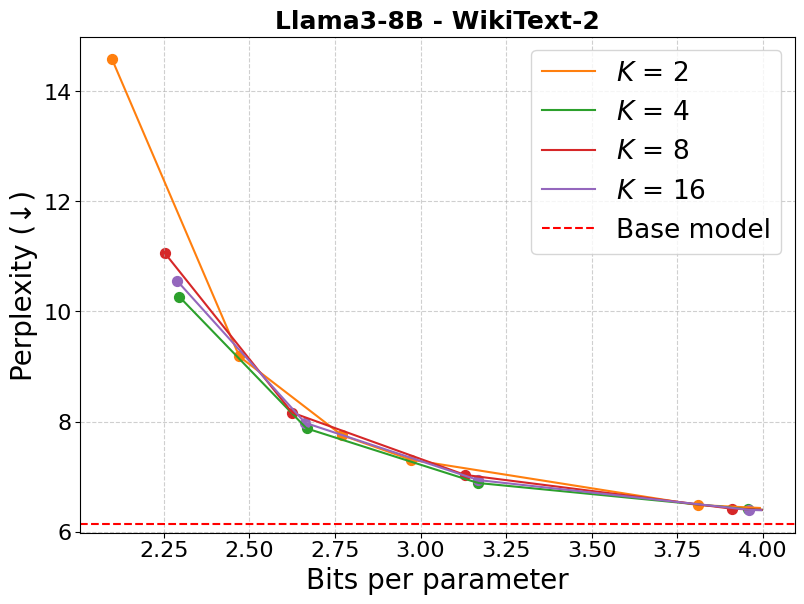

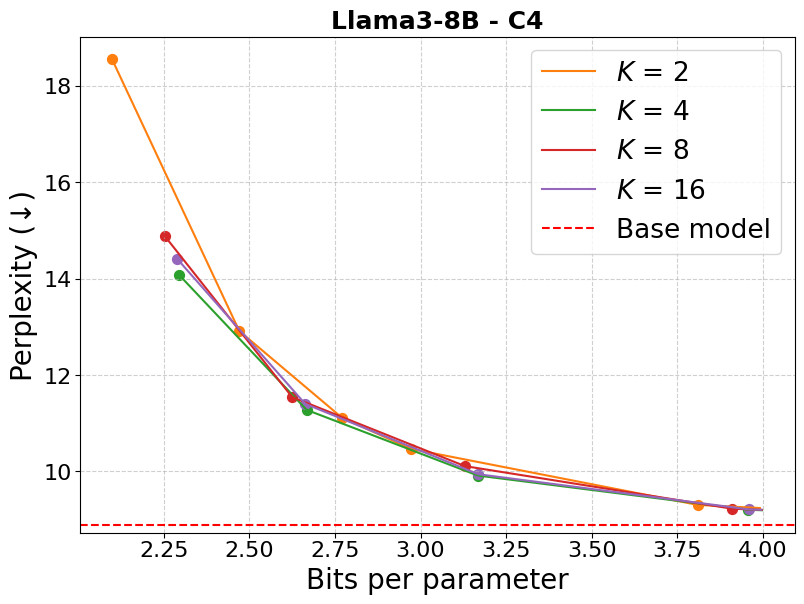

In [35]:
my_ylim = {
    'Llama3-8B': {
        # --- PPL ---
        'ppl_c4': (8.87, 9.4),   ## main
        # 'ppl_c4': (8.87, 20),
        # 'ppl_wikitext2': (6.1, 15), # ecsq
        'ppl_wikitext2': (6.1, 6.9), ## main
        # 'ppl_wikitext2': (6, 15),
        # 'ppl_wikitext2': (6, 11),    ## data free
        # 'ppl_wikitext2': (5.5, 9), # Current Setting
        # --- Accuracy ---
        # 'commonsense': (60, 80),
        'commonsense': (68.5, 71.05),
        # 'zeroshot': (68.5, 71),
        'mmlu': (57, 62.3),
        # 'mse': (, ),
    },
    'Llama2-7B': {
        # 'ppl_c4': (6.97, 7.3),   ## main
        'ppl_c4': (6.97, 7.6),     ## main v2
        # 'ppl_c4': (6.97, 10),    ## ReALLM
        'ppl_wikitext2': (5.4, 7.8), ## data free
        # 'ppl_wikitext2': (5.4, 7.5), ## ReALLM
        'commonsense': (65, 67.33),
        'zeroshot': (65, 70),
        'mmlu': (34, 44),
    },
    'Llama2-13B': {
        # 'ppl_c4': (6.46, 6.7),   ## main
        'ppl_c4': (6.46, 6.92),    ## main v2
        'ppl_wikitext2': (4.8, 5.85), ## data free
        'commonsense': (60, 70),
        'zeroshot': (60, 70),
    },
    'Mixtral': {
        # 'mmlu': (None, 68.2),
        # 'commonsense': (73.5, 75.3),
    },
    'GPT-OSS 20B':{
        # 'mmlu': (25, 60),
        'commonsense': (58, 64),
    },
}
exp_name = [
    # 'GPTQ',
    # 'AWQ',
    # 'SpinQ',
    # 'QuIP#_no_e2e',
    # 'QTIP_no_e2e',
    # 'QTIP_no_ft',
    # 'ft1',
    # 'LLM-QAT',
    # 'BitDistiller',
    # 'ReALLM',
    # 'VQ_rnorm',
    # 'NWC_Avg',
    # 'NWC_ql_ldlq128_rnorm_ft',
    # 'NWC_ql_ldlq128_rnorm_ft_seed2',
    # 'NWC_ql_ldlq128_rnorm_ft_seed3',
    # 'ql_ldlq128_rnorm_ft_nres1',
    # 'ql_ldlq128_normalization_search_ft',
    # 'gemma-3-4b-pt_ql_ldlq128_normalization_search_ft',
    # 'ql_ldlq128_rnorm_ft',
    # 'gpt-oss-20b_ql_ldlq64_rnorm_ft',
    # 'gpt-oss-20b_ql_ldlq64_rnorm',
    # 'gpt-oss-20b_ql_ldlq64_normalization_search'
    # 'ReALLM_noft',
    # 'SeedLM',
    # 'QuIP#_no_ft',
    # 'QTIP',
    # 'QTIP_noft_identity_hessian',
### ablations
    # 'ql_ldlq128_rnorm_ft',
    # 'ql_ldlq128_rnorm_ft_size4_encdim64_M4',
    # 'ql_ldlq128_rnorm_ft_seed2',
    # 'ql_ldlq128_rnorm_ft_seed3',
    # 'ql_ldlq128_rnorm_ft_nres2',
    # 'ql_ldlq128_rnorm_ft_nres1',
    # 'ql_ldlq128_normalization_search_ft',
    # 'noLN_ql_ldlq128_rnorm_ft',
    # 'ql_rnorm',
    # 'ql_patch_row_noLN_(rnorm)_rnorm',
    # 'ql_patch_row_noLN_rnorm',
    # 'ql_patch_row_noLN_(rnorm)_rnorm_ldlq128',
    # 'ql_patch_row_noLN_rnorm_ldlq128',
    # 'ql_patch_row_noLN_rnorm_ldlq128_ft',
    # 'ql_patch_row_noLN_(rnorm)_rnorm_ldlq128_ft'
    # 'ecsq',
    # 'ecsq_rnorm',
    # 'ecsq_rnorm_scaleH',
    # 'ecsq_rnorm_scaleHinv',
    # 'ecsq_cnorm_scaleH',
    # 'ecsq_normalization_search_scaleH',
    # 'uniform_ql1_rnorm',
    # 'uniform_ql0_rnorm',
    # 'ql',
    'ql_Q2_rnorm',
    'ql_rnorm',
    'ql_Q8_rnorm',
    'ql_Q16_rnorm',
    # 'ql_random_uniform2_rnorm',
    # 'ql_ldlq128_rnorm',
    # 'ql_random_uniform2_ldlq128_rnorm',
    # 'ql_ldlq128_normalization_search_ft',
    # 'ql_ldlq128_rnorm_cs4',
    # 'ql_ldlq128_rnorm',
    # 'ql_ldlq128_normalization_search',
    # 'ql_ldlq128_rnorm_cs64',
]
seed_experiments = {
    'NWC_Avg': [
        'NWC_ql_ldlq128_rnorm_ft',
        'ql_ldlq128_rnorm_ft_nres1',
        'ql_ldlq128_normalization_search_ft',
        ]
    # 'NWC_Avg': [
    #     'NWC_ql_ldlq128_rnorm_ft',
    #     'NWC_ql_ldlq128_rnorm_ft_seed2',    
    #     'NWC_ql_ldlq128_rnorm_ft_seed3',
    #     'ql_ldlq128_rnorm_ft_nres1',
    #     'ql_ldlq128_normalization_search_ft',
    #     ]
}
plot_labels = [
    # 'GPTQ',
    # 'AWQ',
    # 'SpinQ',
    # r'QuIP#$^⁎$',
    # 'QuIP',
    # r'QTIP$^⁎$',
    # 'QTIP',
    # 'ReALLM',
    # 'SeedLM',
    # 'QTIP',
    # 'NWC (Ours)',
    # 'NWC (row)',
    # r'NWC$^†$',
    # r'QTIP$^†$',
    # r'NWC$^†$ (Ours)',
    # 'LLM-QAT',
    # 'BitDistiller',
    # 'ReALLM (no finetuning)',
    # 'NWC (data-free)',
    # 'ECSQ',
    # 'ECSQ + Learned transforms',
    # '+ Intra-layer error feedback',
    # '+ Inter-layer recovery fine-tuning',
    # 'Neural Compressor',
    # '+ Importance awareness'
    # 'Global',
    # 'Tensor-wise',
    # 'Channel-wise',
    # 'nonlinear SQ',
    # 'Vector Quantizer',
    # 'Entropy coding',
    # r'NWC$^†$ (CS 4)',
    # r'NWC$^†$ (CS 16)',
    # r'NWC$^†$ (CS 64)',
    r'$K$ = 2',
    r'$K$ = 4',
    r'$K$ = 8',
    r'$K$ = 16',
]
metrics = [
    ('ppl_wikitext2', 'WikiText-2'),
    ('ppl_c4', 'C4'),
    # ('mse', 'MSE'),
    # ('mse_normed', 'MSE normed'),
    # ('proxy_err', 'proxy_err'),
    # ('zeroshot','Zero-shot '), 
    # ('commonsense', 'Common-sense'),
    # ('commonsense_', 'commonsense_'),
    # ('mmlu', 'MMLU'),
    # ('arc_challenge', 'arc_challenge'),
    # ('arc_easy', 'arc_easy'),
    # ('boolq', 'boolq'),
    # ('piqa', 'piqa'),
    # ('winogrande', 'winogrande'),
    # ('hellaswag', 'hellaswag'),
    # ('qat', 'Zero-shot'),
]
models = [
    'Llama3-8B',
    # 'Llama2-7B',
    # 'Llama2-13B',
    # 'Mixtral',
    # 'Qwen3Moe',
    # 'GPT-OSS 20B',
    # 'Gemma3-4B', 
]
my_zoom = {
    'ppl_wikitext2':
        (1.9, 4.0),
        # (3.3, 6.01),   ## main
        # (3.0, 6.01),   ## mixtral
        # (2.92, 6.05),   ## main v2
        # (1.7, 6),      ## full range
        # (1.8, 6)      ## e2e
        # (1.8, 4.5)    ## ReALLM, LLMQAT
        # (1.8, 4.1)    ## Normalization ablation
        # (2.5, 6.02)   ## VQ
        # (2.0, 5.0)    ## data free 
        # (2.5, 8)      ## data free 
        # (2, 6)        ## ablation 
        # (2, 4.0)      ## ablation
        # (2.15, 4.1),      ## ecsq
        # (2.0, 3.2),      ## ecsq mse
    'commonsense': 
        (1.9, 8), 
        # (2.7, 6.01), # main
        # (2.7, 6.5),
        # (1.7, 6),
    # 'qat': (2.1, 4.1),
}
my_zoom['ppl_c4'] = my_zoom['ppl_wikitext2']
my_zoom['mse'] = my_zoom['ppl_wikitext2']
my_zoom['mse_normed'] = my_zoom['ppl_wikitext2']
my_zoom['proxy_err'] = my_zoom['ppl_wikitext2']
my_zoom['zeroshot'] = my_zoom['commonsense']
my_zoom['mmlu'] = my_zoom['commonsense']
if 'df_final' in locals():
    plot_results_from_dataframe(
        df_final, 
        models = models,
        exp_names=exp_name, 
        plot_labels=plot_labels, 
        metrics=metrics,
        zoom_ranges=my_zoom,
        # ylim_settings=my_ylim,
        ylim_settings=None,
        seed_experiments=seed_experiments,
        logscale=False,
        show_title = True,
        show_legend = True,
        error_bar = True
    )
else:
    print("df_master 데이터프레임을 먼저 로드해주세요.")

In [22]:
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy.interpolate import make_interp_spline
# import matplotlib.cm as cm
# import os
# import pandas as pd

# #################################################################
# ##                      PLOT CONFIGURATION                     ##
# #################################################################
# # (설정 값들은 기존 코드 그대로 유지)


# SPLINE_ORDER = 1
# plt.rcParams['font.size'] = 16
# plt.rcParams['axes.titlesize'] = 18
# plt.rcParams['axes.labelsize'] = 18
# # plt.rcParams['axes.labelsize'] = 23
# plt.rcParams['xtick.labelsize'] = 16
# plt.rcParams['ytick.labelsize'] = 16
# plt.rcParams['legend.fontsize'] = 16
# # plt.rcParams['legend.fontsize'] = 20
# plt.rcParams['figure.titlesize'] = 20

# # Create a directory to save plots if it doesn't exist
# output_dir = 'plots'
# os.makedirs(output_dir, exist_ok=True)

# #################################################################
# ##                      HELPER FUNCTION                        ##
# #################################################################
# def replace_none_with_nan(data):
#     """None 값을 np.nan으로 변환하여 계산에 용이하게 합니다."""
#     # Series나 ndarray가 들어올 경우 list로 변환하거나 바로 처리
#     if hasattr(data, 'tolist'):
#         data = data.tolist()
#     return np.array([np.nan if val is None else val for val in data], dtype=float)

# #################################################################
# ##                         MAIN SCRIPT                         ##
# #################################################################
# if not plot_labels or len(plot_labels) != len(plot_name):
#     plot_labels = plot_name

# cmap = cm.get_cmap('tab10')
# colors = {}
# idx = 1
# for name in plot_labels:
#     if 'Ours' in name:
#     # if 'NWC' in name:
#         colors[name] = cmap(0)
#     else:
#         colors[name] = cmap(idx)
#         idx += 1

# # df_master가 존재한다고 가정 (이전 단계에서 생성됨)
# # 만약 없다면 csv에서 로드하는 코드가 필요함
# # if 'df_master' not in locals():
# #     print("Warning: 'df_master' not found. Loading from CSV...")
# #     try:
# #         df_master = pd.read_csv('./exp_results_csv/latest.csv')
# #     except FileNotFoundError:
# #         print("Error: CSV file not found. Please run the data preparation script first.")
# #         df_master = pd.DataFrame()

# for m_name in models:
#     # DataFrame에서 해당 모델 데이터만 필터링
#     df_model = df_master[df_master['Model'] == m_name]
    
#     if df_model.empty:
#         print(f"Skipping model {m_name}: No data found.")
#         continue
    
#     # plots_data 대신 df_model을 사용
    
#     for plot_key, y_label in plot_keys:
        
#         # Create a single plot
#         fig, ax = plt.subplots(figsize=(8, 6))

#         for k, label in zip(plot_name, plot_labels):
#             try:
#                 # DataFrame에서 특정 실험(Experiment == k) 필터링
#                 df_exp = df_model[df_model['Experiment'] == k]
                
#                 if df_exp.empty:
#                     # 데이터가 없으면 스킵 (기존 try-catch 흐름 대체)
#                     continue

#                 # 컬럼 존재 여부 확인
#                 if plot_key not in df_exp.columns or 'bpp' not in df_exp.columns:
#                     continue

#                 # 값 추출 (Numpy array로 변환)
#                 bpp_vals = df_exp['bpp'].values
#                 metric_vals = df_exp[plot_key].values

#                 bpp = replace_none_with_nan(bpp_vals)
#                 metric = replace_none_with_nan(metric_vals)

#                 mask = np.isfinite(bpp) & np.isfinite(metric) & (metric < 1000)
#                 if plot_key in ['commonsense', 'zeroshot', 'mmlu', 'qat']:
#                     metric = metric * 100
                
#                 sort_indices = np.argsort(bpp[mask])
#                 bpp_sorted = bpp[mask][sort_indices]
#                 metric_sorted = metric[mask][sort_indices]
                
#                 # if len(bpp_sorted) > SPLINE_ORDER:
#                 if False:
#                     x_smooth = np.linspace(bpp_sorted.min(), bpp_sorted.max(), 300)
#                     spline = make_interp_spline(bpp_sorted, metric_sorted, k=SPLINE_ORDER)
#                     y_smooth = spline(x_smooth)
#                 else:
#                     x_smooth, y_smooth = bpp_sorted, metric_sorted # Not enough points for spline
                
#                 marker = 'o'
#                 # marker = 's' if 'NWC' in label else 'o'
#                 marker_size = 100 if marker == 's' else 50
#                 lw = 2.5 if marker == 's' else 1.5
#                 # linestyle = '-.' if 'gaussian' in k else '-'
#                 linestyle = '-.' if 'qtip' in k.lower() else '-'
#                 color = colors[label]
#                 # linestyle = '-.'
                
#                 # zoom_range = (2.7, 8)
#                 zoom_range = (0, 8)
#                 if 'ppl' in plot_key:
#                     zoom_range = (3.5, 8) 
#                     # zoom_range = (3.5, 6.01) ## main
#                     # zoom_range = (2.7, 6.05) ## main v2
#                     # zoom_range = (1.7, 6) ## full range
#                     # zoom_range = (1.8, 6) ## e2e
#                     # zoom_range = (1.8, 4.5) ## ReALLM, LLMQAT
#                     # zoom_range = (1.8, 4.1) ## Normalization ablation
#                     # zoom_range = (2.5, 6.02) ## VQ
#                     # zoom_range = (2.0, 5.0) ## data free 
#                     # zoom_range = (2.5, 8) ## data free 
#                     # zoom_range = (2, 6) ## ablation 
#                     # zoom_range = (2, 4.0) ## ablation 
#                 if plot_key in ['commonsense', 'zeroshot', 'mmlu']: 
#                     # zoom_range = (2.7, 6.03) # main
#                     zoom_range = (2.7, 6.5)
#                     # zoom_range = (1.7, 6)
#                 if plot_key in ['qat']: 
#                     zoom_range = (2.1, 4.1)
                
#                 zoom_data_mask = (bpp_sorted >= zoom_range[0]) & (bpp_sorted <= zoom_range[1])
#                 zoom_smooth_mask = (x_smooth >= zoom_range[0]) & (x_smooth <= zoom_range[1])
                
#                 # Plotting on the single axis
#                 ax.plot(x_smooth[zoom_smooth_mask], y_smooth[zoom_smooth_mask], linestyle=linestyle, color=color, label=label, alpha=1, lw=lw)
#                 ax.scatter(bpp_sorted[zoom_data_mask], metric_sorted[zoom_data_mask], color=color, marker=marker, s=marker_size, alpha=1)
                
#                 if 'c4' in plot_key:
#                     if '8B' in m_name:
#                         # ax.set_ylim(8.87, 9.4) # main
#                         # ax.set_ylim(8.87, 20)
#                         pass
#                     if '7B' in m_name:
#                         # ax.set_ylim(6.97, 7.3) # main
#                         ax.set_ylim(6.97, 7.6) # main v2
#                         # ax.set_ylim(6.97, 10) # ReALLM
#                         pass
#                     if '13B' in m_name:
#                         # ax.set_ylim(6.46, 6.7) # main
#                         ax.set_ylim(6.46, 6.92) # main v2
#                         pass
#                 if 'wiki' in plot_key:
#                     if '8B' in m_name:
#                         # ax.set_ylim(6,15)
#                         # ax.set_ylim(6.1, 6.9) # main
#                         # ax.set_ylim(6,11) # data free
#                         pass
#                     if '7B' in m_name:
#                         ax.set_ylim(5.4, 7.8) # data free
#                         # ax.set_ylim(5.4, 7.5) # ReALLM
#                         pass
#                     if '13B' in m_name:
#                         ax.set_ylim(4.8, 5.85) # data free
#                         pass
#                 if plot_key in ['commonsense']:
#                     if '8B' in m_name:
#                         ax.set_ylim(68.5,71.05)
#                         pass
#                     if '7B' in m_name:
#                         ax.set_ylim(65, 67.33)
#                         pass
#                     if '13B' in m_name:
#                         ax.set_ylim(60, 70)
#                         pass
#                 if plot_key in ['zeroshot']:
#                     if '8B' in m_name:
#                         # ax.set_ylim(68.5,71)
#                         pass
#                     if '7B' in m_name:
#                         ax.set_ylim(65, 70)
#                         pass
#                     if '13B' in m_name:
#                         ax.set_ylim(60, 70)
#                         pass
#                 if plot_key in ['mmlu']:
#                     if '8B' in m_name:
#                         # ax.set_ylim(57, 62.3)
#                         pass
                        
#             except (KeyError, ValueError) as e:
#                 print(f"Warning: Could not plot '{k}' for '{m_name}' due to error: {e}. Skipping.")
#             except Exception as e:
#                 print(f"An unexpected error occurred while plotting '{k}' for '{m_name}': {e}")
        
#         # Define y-axis label
#         if 'ppl' in plot_key:
#             y_label = 'Perplexity (↓)'
#         elif plot_key in ['commonsense', 'zeroshot', 'qat']: 
#             y_label = 'Avg. accuracy (↑)'
#         elif plot_key in ['mmlu']: 
#             y_label = 'Accuracy (%)'
#         else:
#             y_label = y_label

#         # Apply final plot settings to the single axis
#         # [수정] DataFrame을 사용하여 FP16 Baseline 찾기
#         try:
#             fp16_row = df_model[df_model['Experiment'] == 'FP16']
#             if not fp16_row.empty and plot_key in fp16_row.columns:
#                 # FP16 값이 여러 개일 경우 평균을 사용하거나 첫 번째 값을 사용 (여기서는 평균)
#                 fp16_val = fp16_row[plot_key].mean()
                
#                 if plot_key in ['commonsense', 'zeroshot', 'mmlu', 'qat']:
#                     fp16_val = fp16_val * 100
                
#                 # ax.axhline(y=fp16_val, color='purple', linestyle='--', label='Baseline')
#                 ax.axhline(y=fp16_val, color='r', linestyle='--', label='Base model')
#         except KeyError:
#             pass
            
#         ax.set_xlabel('Bits per parameter')
#         # ax.set_xlabel('Avg. Bits')
#         # ax.set_ylabel(y_label)
#         ax.set_ylabel(" ")
#         ax.grid(True, which='both', linestyle='--', alpha=0.6)
#         # if plot_key not in ['ppl_wikitext2', 'ppl_c4']:
#         ax.legend()
#         ax.set_title(f'{m_name} - {y_label}', weight='bold')
#         if 'mse' in plot_key or 'proxy_err' in plot_key:
#             # ax.set_yscale('log')
#             pass
#         plt.tight_layout()
        
#         # Save the figure to a file
#         filename = os.path.join(output_dir, f'{m_name}_{plot_key}.pdf')
#         plt.savefig(filename, dpi=300)
#         print(f"Plot saved to {filename}")
        
#         # Close the plot to free up memory
#         # plt.close(fig)